In [1]:
import pandas as pd
from sklearn.metrics import classification_report,roc_auc_score, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate
from tensorflow.keras.models import Model

def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

set_seed(42)
results={}
scale=StandardScaler()

2026-05-28 17:34:10.904711: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#import dataframe
df_modelling=pd.read_parquet("../df_modelling.parquet")

Without Rolling Window:

In [3]:
#creating market vector
# 'Stock_Date', 'Closing Price($)', 'relative difference',
#        'comment_published_at_median_YMD', 'number_of_comments_at_date',
#        'comment_likes_agg', 'comment_embeddings_agg', 'comment_sentiment_agg',
#        'sentiment_tensor', 'videos_text_embeddings', 'TargetVariable:Up/Down'
numerical_columns=['Closing Price($) lag1',
'relative difference lag1',
         'number_of_comments_at_date',
    'comment_likes_agg',
    'comment_sentiment_agg',
     'sentiment_tensor']

print(df_modelling.columns)


#concating the embeddings separately
df_modelling['embeddings_vector']=df_modelling.apply(lambda row: np.concatenate((row['comment_embeddings_agg'], row['videos_text_embeddings'])), axis=1)


Index(['Stock_Date', 'Closing Price($)', 'relative difference',
       'comment_published_at_YMD', 'number_of_comments_at_date',
       'comment_likes_agg', 'comment_embeddings_agg', 'comment_sentiment_agg',
       'sentiment_tensor', 'videos_text_embeddings', 'Difference',
       'videos_text_embeddings_window', 'TargetVariable:Up/Down',
       'Closing Price($) lag1', 'relative difference lag1',
       'Calendar_Diff_Days'],
      dtype='object')


In [4]:
#function for creating sequences
def create_sequences(embeddings, numeric, target, sequence_length):
    X_emb_seq = []
    X_num_seq = []
    y_seq = []

    for i in range(sequence_length, len(embeddings)):
        X_emb_seq.append(embeddings[i-sequence_length:i])
        X_num_seq.append(numeric[i-sequence_length:i])
        y_seq.append(target[i])

    return (
        np.array(X_emb_seq),
        np.array(X_num_seq),
        np.array(y_seq)
    )

In [5]:
# embeddings_array=np.stack(df_modelling['embeddings_vector'])
# Embeddings_reduced=embeddings_array 
# numerical_values=np.stack(df_modelling[numerical_columns].values)
# y = df_modelling['TargetVariable:Up/Down'].values

sequence_length = 20  # timesteps

#splitting data
embeddings_array = np.stack(df_modelling['embeddings_vector'])
numerical_values = np.stack(df_modelling[numerical_columns].values)
y = df_modelling['TargetVariable:Up/Down'].values


N = len(embeddings_array)
#train 70% val 20% test 10%
train_end = int(N * 0.7)
val_end = int(N * 0.9)

# Raw splits
# TRAIN
emb_train_raw = embeddings_array[:train_end]
num_train_raw = numerical_values[:train_end]
y_train_raw   = y[:train_end]

# VALIDATION
emb_val_raw = embeddings_array[train_end-sequence_length:val_end]
num_val_raw = numerical_values[train_end-sequence_length:val_end]
y_val_raw   = y[train_end-sequence_length:val_end]

# TEST
emb_test_raw = embeddings_array[val_end-sequence_length:]
num_test_raw = numerical_values[val_end-sequence_length:]
y_test_raw   = y[val_end-sequence_length:]


num_train_raw = scale.fit_transform(num_train_raw)
num_val_raw = scale.transform(num_val_raw)
num_test_raw = scale.transform(num_test_raw)


In [6]:

#LSTM will look 20 steps in the past
X_emb_train, X_num_train, y_train = create_sequences(emb_train_raw, num_train_raw, y_train_raw, sequence_length)
X_emb_val, X_num_val, y_val = create_sequences(emb_val_raw, num_val_raw, y_val_raw, sequence_length)
X_emb_test, X_num_test, y_test = create_sequences(emb_test_raw, num_test_raw, y_test_raw, sequence_length)

In [7]:

# Inputs
embedding_input = Input(shape=(sequence_length,X_emb_train.shape[2]))   # change 50 to your seq_len
numeric_input = Input(shape=(sequence_length,X_num_train.shape[2]))

# Embeddings branch
x = LSTM(64, return_sequences=True)(embedding_input)
x = LSTM(32)(x)

#numerical branch
z= LSTM(16, return_sequences=True)(numeric_input)
z= LSTM(8)(z)

# Concatenate numeric features
x = Concatenate()([x, z])

# Output
output = Dense(1, activation='sigmoid')(x)

# Build model
model = Model(inputs=[embedding_input, numeric_input], outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20, 512)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 20, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 20, 64)    │    147,712 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 20, 16)    │      1,472 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 8)         │        800 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 40)        │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │         41 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 162,441 (634.54 KB)

 Trainable params: 162,441 (634.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    [X_emb_train, X_num_train],  # inputs
    y_train,                        # labels
    validation_data=([X_emb_val, X_num_val], y_val),
    epochs=200,                      # start with 10, can increase
    batch_size=32,                  # tune depending on memory
    shuffle=False
)


Epoch 1/200


/opt/anaconda3/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_1']. Received: the structure of inputs=('*', '*')
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.4335 - loss: 0.7039 - val_accuracy: 0.5306 - val_loss: 0.6860
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4557 - loss: 0.6962 - val_accuracy: 0.5816 - val_loss: 0.6896
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4903 - loss: 0.6954 - val_accuracy: 0.4796 - val_loss: 0.6925
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4903 - loss: 0.6930 - val_accuracy: 0.5204 - val_loss: 0.6930
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5283 - loss: 0.6891 - val_accuracy: 0.5102 - val_loss: 0.6929
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5735 - loss: 0.6844 - val_accuracy: 0.5204 - val_loss: 0.6937
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5743 - loss: 0.6779 - val_accuracy: 0.5000 - val_loss: 0.6951
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5878 - loss: 0.6663 - val_accuracy: 0.4286 - val_l

In [9]:
thresholds=np.arange(0.0,1.01,0.1)
f1_scores=[]
best_f1=0

#selecting best threshold on val data

y_prob = model.predict([X_emb_val, X_num_val])
for threshold in thresholds:
    y_pred_tr = (y_prob > threshold).astype(int)
    report=classification_report(y_val, y_pred_tr, output_dict=True)
    f1_scores.append(report['macro avg']['f1-score'])

#deciding the best index    
f1_score=max(f1_scores)
index_tr=f1_scores.index(f1_score)
threshold=thresholds[index_tr]

#now deciding F1 on test data with the decided best threshold
y_prob = model.predict([X_emb_test, X_num_test])
y_pred_tr = (y_prob > threshold).astype(int)
report=classification_report(y_test, y_pred_tr, output_dict=True)
f1=report['macro avg']['f1-score']
print(f"Best Result is f1 {f1} at threshold {threshold}")
results["without Window"]=[f1, threshold, report]

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Best Result is f1 0.4889445139758031 at threshold 0.4


/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
              precision    recall  f1-score   support

           0       0.42      0.65      0.51        20
           1       0.61      0.38      0.47        29

    accuracy                           0.49        49
   macro avg       0.52      0.51      0.49        49
weighted avg       0.53      0.49      0.49        49

confusion_matrix is:


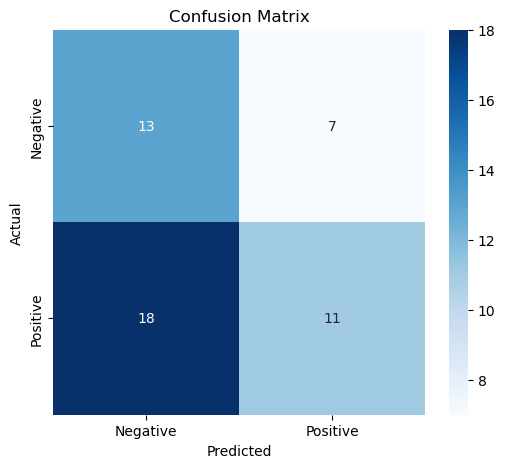

In [10]:
y_prob = model.predict([X_emb_test, X_num_test])
y_pred = (y_prob > threshold).astype(int)
print(classification_report(y_test, y_pred))

print("confusion_matrix is:")
cm=confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

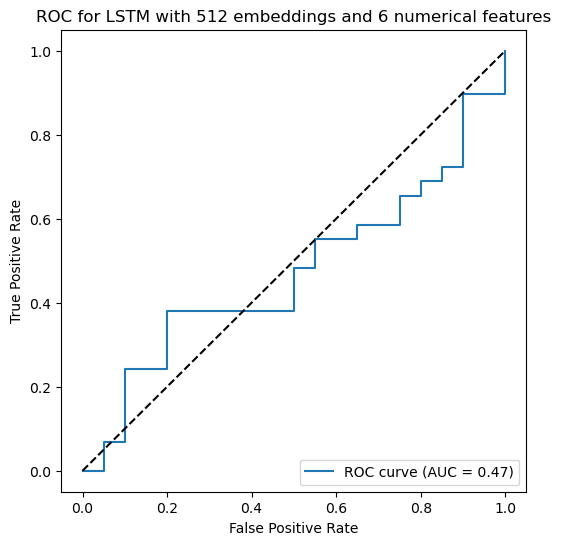

In [11]:
auc=roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.title("ROC for LSTM with 512 embeddings and 6 numerical features")
plt.show()

With Rolling Window

In [12]:

numerical_columns=['Closing Price($) lag1',
'relative difference lag1',
         'number_of_comments_at_date',
    'comment_likes_agg',
    'comment_sentiment_agg',
     'sentiment_tensor']

print(df_modelling.columns)


#concating the embeddings separately
df_modelling['embeddings_vector']=df_modelling.apply(lambda row: np.concatenate((row['comment_embeddings_agg'], row['videos_text_embeddings_window'])), axis=1)


Index(['Stock_Date', 'Closing Price($)', 'relative difference',
       'comment_published_at_YMD', 'number_of_comments_at_date',
       'comment_likes_agg', 'comment_embeddings_agg', 'comment_sentiment_agg',
       'sentiment_tensor', 'videos_text_embeddings', 'Difference',
       'videos_text_embeddings_window', 'TargetVariable:Up/Down',
       'Closing Price($) lag1', 'relative difference lag1',
       'Calendar_Diff_Days', 'embeddings_vector'],
      dtype='object')


In [13]:
#function for creating sequences
def create_sequences(embeddings, numeric, target, sequence_length):
    X_emb_seq = []
    X_num_seq = []
    y_seq = []

    for i in range(sequence_length, len(embeddings)):
        X_emb_seq.append(embeddings[i-sequence_length:i])
        X_num_seq.append(numeric[i-sequence_length:i])
        y_seq.append(target[i])

    return (
        np.array(X_emb_seq),
        np.array(X_num_seq),
        np.array(y_seq)
    )

In [14]:


sequence_length = 20  # timesteps


#splitting data
embeddings_array = np.stack(df_modelling['embeddings_vector'])
numerical_values = np.stack(df_modelling[numerical_columns].values)
y = df_modelling['TargetVariable:Up/Down'].values


N = len(embeddings_array)
#train 70% val 20% test 10%
train_end = int(N * 0.7)
val_end = int(N * 0.9)

# TRAIN
emb_train_raw = embeddings_array[:train_end]
num_train_raw = numerical_values[:train_end]
y_train_raw   = y[:train_end]

# VALIDATION
emb_val_raw = embeddings_array[train_end-sequence_length:val_end]
num_val_raw = numerical_values[train_end-sequence_length:val_end]
y_val_raw   = y[train_end-sequence_length:val_end]

# TEST
emb_test_raw = embeddings_array[val_end-sequence_length:]
num_test_raw = numerical_values[val_end-sequence_length:]
y_test_raw   = y[val_end-sequence_length:]


num_train_raw = scale.fit_transform(num_train_raw)
num_val_raw = scale.transform(num_val_raw)
num_test_raw = scale.transform(num_test_raw)


In [15]:

#LSTM will look 20 steps in the past
X_emb_train, X_num_train, y_train = create_sequences(emb_train_raw, num_train_raw, y_train_raw, sequence_length)
X_emb_val, X_num_val, y_val = create_sequences(emb_val_raw, num_val_raw, y_val_raw, sequence_length)
X_emb_test, X_num_test, y_test = create_sequences(emb_test_raw, num_test_raw, y_test_raw, sequence_length)

In [16]:
# Inputs
embedding_input = Input(shape=(sequence_length,X_emb_train.shape[2]))   # change 50 to your seq_len
numeric_input = Input(shape=(sequence_length,X_num_train.shape[2]))

# Embeddings branch
x = LSTM(64, return_sequences=True)(embedding_input)
x = LSTM(32)(x)

#numerical branch
z= LSTM(16, return_sequences=True)(numeric_input)
z= LSTM(8)(z)

# Concatenate numeric features
x = Concatenate()([x, z])

# Output
output = Dense(1, activation='sigmoid')(x)

# Build model
model = Model(inputs=[embedding_input, numeric_input], outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 20, 512)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 20, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 20, 64)    │    147,712 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 20, 16)    │      1,472 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 32)        │     12,416 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ (None, 8)         │        800 │ lstm_6[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 40)        │          0 │ lstm_5[0][0],     │
│ (Concatenate)       │                   │            │ lstm_7[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         41 │ concatenate_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 162,441 (634.54 KB)

 Trainable params: 162,441 (634.54 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(
    [X_emb_train, X_num_train],  # inputs
    y_train,                        # labels
    validation_data=([X_emb_val, X_num_val], y_val),
    epochs=200,                      # start with 10, can increase
    batch_size=32,                  # tune depending on memory
    shuffle=False
)

model.save("best_model_LSTM.keras")

Epoch 1/200


/opt/anaconda3/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_8', 'keras_tensor_9']. Received: the structure of inputs=('*', '*')
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.4734 - loss: 0.6939 - val_accuracy: 0.4592 - val_loss: 0.6963
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5632 - loss: 0.6897 - val_accuracy: 0.4490 - val_loss: 0.6996
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5329 - loss: 0.6888 - val_accuracy: 0.4490 - val_loss: 0.7010
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5682 - loss: 0.6863 - val_accuracy: 0.5000 - val_loss: 0.7013
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5606 - loss: 0.6825 - val_accuracy: 0.5102 - val_loss: 0.7026
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5544 - loss: 0.6762 - val_accuracy: 0.4286 - val_loss: 0.7083
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5597 - loss: 0.6619 - val_accuracy: 0.4796 - val_loss: 0.7365
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5970 - loss: 0.6633 - val_accuracy: 0.4796 - val_l

In [18]:
thresholds=np.arange(0.0,1.01,0.1)
f1_scores=[]
best_f1=0

#selecting best threshold on val data

y_prob = model.predict([X_emb_val, X_num_val])
for threshold in thresholds:
    y_pred_tr = (y_prob > threshold).astype(int)
    report=classification_report(y_val, y_pred_tr, output_dict=True)
    f1_scores.append(report['macro avg']['f1-score'])

#deciding the best index    
f1_score=max(f1_scores)
index_tr=f1_scores.index(f1_score)
threshold=thresholds[index_tr]

#now deciding F1 on test data with the decided best threshold
y_prob = model.predict([X_emb_test, X_num_test])
y_pred_tr = (y_prob > threshold).astype(int)
report=classification_report(y_test, y_pred_tr, output_dict=True)
f1=report['macro avg']['f1-score']
print(f"Best Result is f1 {f1} at threshold {threshold}")
results["with Window"]=[f1, threshold, report]

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Best Result is f1 0.5306122448979592 at threshold 0.7000000000000001


/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
              precision    recall  f1-score   support

           0       0.45      0.65      0.53        20
           1       0.65      0.45      0.53        29

    accuracy                           0.53        49
   macro avg       0.55      0.55      0.53        49
weighted avg       0.57      0.53      0.53        49

confusion_matrix is:


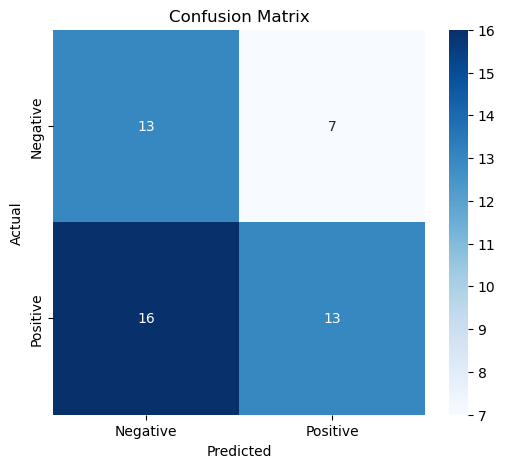

In [19]:
y_prob = model.predict([X_emb_test, X_num_test])
y_pred = (y_prob > threshold).astype(int)
print(classification_report(y_test, y_pred))

print("confusion_matrix is:")
cm=confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

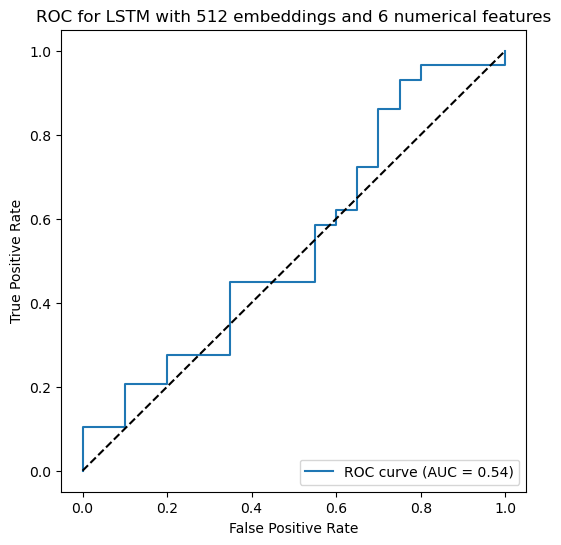

In [20]:
auc=roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.title("ROC for LSTM with 512 embeddings and 6 numerical features")
plt.show()

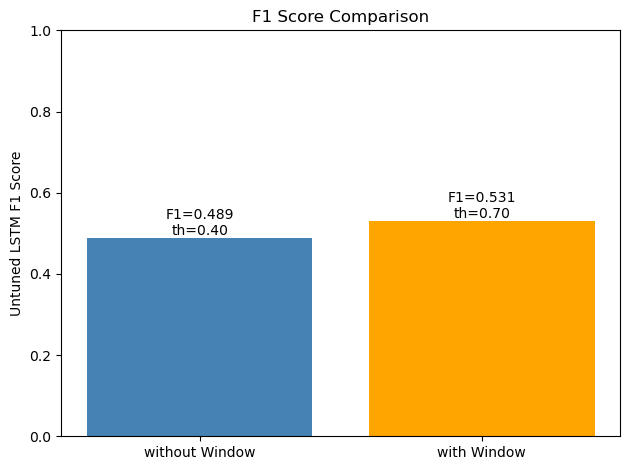

In [21]:
labels = list(results.keys())

f1_scores = [v[0] for v in results.values()]
thresholds = [v[1] for v in results.values()]

bars = plt.bar(labels, f1_scores, color=["steelblue", "orange"])

plt.ylabel("Untuned LSTM F1 Score")
plt.title("F1 Score Comparison")
plt.ylim(0, 1)

# Add F1 + threshold as text
for bar, f1, th in zip(bars, f1_scores, thresholds):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"F1={f1:.3f}\nth={th:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Conclusion: LSTM works better with rolling window
